# Delta Hedging in the Black-Scholes Model

## Problem Statement

The aim of this exercise is to study the influence of trading frequency on the variance of a portfolio consisting of one **short call** position and the corresponding hedging strategy. The theoretical framework is the Black-Scholes model.

---

## 1. Theoretical Framework

### 1.1 Market Model

We consider a financial market defined on the time interval $[0,T]$, composed of two tradeable assets:

- **Risky asset** with price $(S(t))_{0 \le t \le T}$ following a geometric Brownian motion:
$$
dS(t) = S(t)\mu\,dt + S(t)\sigma\,dW(t), \qquad S(0) = x,
$$
where $\mu$ is the drift rate, $\sigma > 0$ is the volatility, and $(W(t))_{t \ge 0}$ is a standard Brownian motion.

- **Money market account** $(B(t))_{0 \le t \le T}$ evolving according to:
$$
dB(t) = B(t) r(t)\,dt, \qquad B(0) = 1,
$$
where $r(t)$ denotes the risk-free interest rate (assumed deterministic).

### 1.2 European Call Option

We consider a European call option written on asset $S$, with strike price $K$ and maturity $T$. The payoff at expiration is:
$$
\text{Payoff} = \max\{0, S(T) - K\}
$$

We denote $V(t,S(t))$ as the Black-Scholes option price at time $t$, and $V = V(0,x)$ as the initial price.

### 1.3 Delta-Hedging Strategy

The delta-hedging strategy is based on the sensitivity of the option price with respect to the underlying asset:
$$
\Delta(t) = \partial_2 V(t,S(t))
$$
where $\partial_2 V$ denotes the partial derivative of $V$ with respect to its second argument.

At time $t=0$, the amount $V$ is invested in a hedging portfolio $\pi$ consisting of:
- $\Delta(0) = \partial_2 V(0,x)$ units of the risky asset $S$
- A position $\big[ V - S(0)\Delta(0) \big] B(0)^{-1}$ in the money market account

At any time $t \in (0,T)$, the position is:
$$
\left(
\Delta(t) = \partial_2 V(t,S(t)),
\;
\big[ V(t,S(t)) - S(t)\Delta(t) \big] B(t)^{-1}
\right)
$$

The portfolio value is therefore:
$$
\pi(t) = \Delta(t)S(t) + \beta(t)B(t) = V(t,S(t))
$$
where $\beta(t) := \big[V(t,S(t)) - S(t)\Delta(t)\big]\,B(t)^{-1}$.

---

## 2. Problem 1: Self-Financing Property

### 2.1 Definition

A strategy $(\Delta(t),\beta(t))$ is said to be **self-financing** if any change in the portfolio value comes solely from changes in the prices of the held assets:
$$
d\pi(t) = \Delta(t)\,dS(t) + \beta(t)\,dB(t)
$$

Intuitively, there is **no capital injection or withdrawal** during portfolio rebalancing.

### 2.2 Proof of Self-Financing Property

By construction, the portfolio always has the same value as the option: $\pi(t) = V(t,S(t))$. Differentiating this identity, we obtain:
$$
d\pi(t) = dV(t,S(t))
$$

The option price $V(t,S(t))$ satisfies the **Black-Scholes equation**:
$$
\frac{\partial V}{\partial t} + rS\frac{\partial V}{\partial S} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} = rV
$$

Applying Itô's formula to $V(t,S(t))$ and using the Black-Scholes equation, we show that:
$$
dV(t,S(t)) = \frac{\partial V}{\partial t}dt + \frac{\partial V}{\partial S}dS + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}dt = \frac{\partial V}{\partial S}dS + r\left(V - S\frac{\partial V}{\partial S}\right)dt
$$

Since $\Delta(t) = \frac{\partial V}{\partial S}(t,S(t))$ and $\beta(t) = \frac{V(t,S(t)) - S(t)\Delta(t)}{B(t)}$, we have:
$$
dV(t,S(t)) = \Delta(t)\,dS(t) + \beta(t)rB(t)dt = \Delta(t)\,dS(t) + \beta(t)\,dB(t)
$$

since $dB(t) = rB(t)dt$. Therefore:
$$
d\pi(t) = dV(t,S(t)) = \Delta(t)\,dS(t) + \beta(t)\,dB(t)
$$

which is exactly the self-financing condition. **The strategy is self-financing.**

---

## 3. Continuous vs. Discrete-Time Hedging

### 3.1 Continuous-Time Hedging

Under the assumption of **continuous** portfolio adjustment, this strategy allows perfect replication of the option payoff:
$$
\pi(T) = V(T,S(T)) = \max\{0, S(T) - K\}
$$

### 3.2 Discrete-Time Hedging

The assumption of continuous portfolio adjustment is unrealistic in practice. In a more realistic setting, the hedging portfolio can only be rebalanced at discrete dates.

We divide the interval $[0,T]$ into $n$ subintervals of length $\delta = T/n$. At each rebalancing date $t = k\delta$ ($k = 0, 1, \ldots, n$), we adjust the portfolio according to the current delta $\Delta(k\delta) = \partial_2 V(k\delta, S(k\delta))$, then maintain this position until the next rebalancing date.

When hedging is performed in discrete time, the final portfolio value $\pi_n(T)$ no longer exactly matches the option payoff. This results in a **hedging error**:
$$
\varepsilon_n := \pi_n(T) - \max\{0, S(T) - K\}
$$

which depends on the trajectory followed by the underlying asset and the rebalancing frequency $n$. The objective of this project is to study this error numerically and analyze its behavior as the trading frequency increases.

---

## 4. Numerical Methodology

To study this convergence numerically, we simulate a large number of trajectories (1000 Monte Carlo simulations) for different values of $n$. For each trajectory:

1. **Generate a price path** $(x, S(\delta), S(2\delta), \ldots, S(n\delta) = S(T))$ using Euler discretization:
$$
S_{k+1} = S_k + S_k \mu \delta + S_k \sigma \sqrt{\delta} \mathcal{N}(0,1),
$$
where $S_k$ approximates $S(k\delta)$ and $\mathcal{N}(0,1)$ is a sample from a standard normal distribution.

2. **Compute the hedging portfolio dynamics** $(\pi_n(0), \pi_n(\delta), \ldots, \pi_n(T))$ by rebalancing at each date $k\delta$ according to the current delta.

3. **Store the hedging error** $\varepsilon_n = \pi_n(T) - \max\{0, S(T) - K\}$.

4. **Plot histograms** of errors for different values of $n$ and observe that as $n$ increases, the histogram converges to a Dirac mass at 0.


---

## 5. Implementation Setup

### 5.1 Import Libraries


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)


### 5.2 Model Parameters

We use the following parametrization as specified in the problem:
- $r = 10\%$ per annum (risk-free rate)
- $\sigma = 20\%/\sqrt{\text{year}}$ (volatility)
- $x = 100$ Euros (initial asset price)
- $K = 90$ Euros (strike price)
- $T = 3$ months = 0.25 years (maturity)

Time is measured in years: 1 year = 12 months, 1 month = 4 weeks, 1 week = 7 days.

We test the following trading frequencies:
- $n = 0$: No hedging
- $n = 1$: Single hedging
- $n = 3$: Monthly hedging
- $n = 12$: Weekly hedging
- $n = 84$: Daily hedging


In [2]:
# Model parameters
r = 0.10          # Risk-free rate (10% per annum)
sigma = 0.20      # Volatility (20% per sqrt(year))
x = 100.0         # Initial asset price (Euros)
K = 90.0          # Strike price (Euros)
T = 3/12          # Maturity (3 months = 0.25 years)

# Simulation parameters
n_simulations = 1000  # Number of Monte Carlo simulations

# Trading frequencies to test
n_values = [0, 1, 3, 12, 84]

print("Simulation Parameters:")
print(f"  Risk-free rate r = {r*100:.1f}%")
print(f"  Volatility = {sigma*100:.1f}%")
print(f"  Initial price S(0) = {x:.2f} Euros")
print(f"  Strike K = {K:.2f} Euros")
print(f"  Maturity T = {T:.3f} years ({T*12:.0f} months)")
print(f"  Number of simulations = {n_simulations}")
print(f"\nTrading frequencies tested: n = {n_values}")


Simulation Parameters:
  Risk-free rate r = 10.0%
  Volatility = 20.0%
  Initial price S(0) = 100.00 Euros
  Strike K = 90.00 Euros
  Maturity T = 0.250 years (3 months)
  Number of simulations = 1000

Trading frequencies tested: n = [0, 1, 3, 12, 84]


---

## 6. Problem 2: Implementation of Discrete-Time Delta-Hedging

### 6.1 Black-Scholes Functions for European Call Option


In [3]:
def black_scholes_call_price(S, K, T, r, sigma, t=0):
    """
    Compute the price of a European call option using Black-Scholes formula.
    
    Parameters:
    -----------
    S : float
        Current price of the underlying asset
    K : float
        Strike price
    T : float
        Option maturity (in years)
    r : float
        Risk-free interest rate (continuous)
    sigma : float
        Volatility of the underlying asset
    t : float
        Current time (default 0)
    
    Returns:
    --------
    float : Call option price
    """
    tau = T - t
    if tau <= 0:
        # At expiration, price equals payoff
        return max(0, S - K)
    
    d_plus = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d_minus = d_plus - sigma * np.sqrt(tau)
    
    price = S * norm.cdf(d_plus) - K * np.exp(-r * tau) * norm.cdf(d_minus)
    return price


def black_scholes_delta(S, K, T, r, sigma, t=0):
    """
    Compute the delta (sensitivity to underlying price) of a European call option.
    
    Parameters:
    -----------
    S : float
        Current price of the underlying asset
    K : float
        Strike price
    T : float
        Option maturity (in years)
    r : float
        Risk-free interest rate (continuous)
    sigma : float
        Volatility of the underlying asset
    t : float
        Current time (default 0)
    
    Returns:
    --------
    float : Call option delta
    """
    tau = T - t
    if tau <= 0:
        # At expiration, delta is 1 if S > K, 0 otherwise
        return 1.0 if S > K else 0.0
    
    d_plus = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    delta = norm.cdf(d_plus)
    return delta


### 6.2 Discrete-Time Hedging Simulation Function


In [4]:
def simulate_hedging_error(n, mu, r, sigma, x, K, T, n_simulations=1000):
    """
    Simulate discrete-time delta-hedging strategy and compute hedging error.
    
    Parameters:
    -----------
    n : int
        Number of hedging periods (0 = no hedging)
    mu : float
        Drift rate of the underlying asset
    r : float
        Risk-free interest rate
    sigma : float
        Volatility
    x : float
        Initial asset price
    K : float
        Option strike
    T : float
        Maturity (in years)
    n_simulations : int
        Number of Monte Carlo simulations
    
    Returns:
    --------
    numpy.ndarray : Array of hedging errors for each simulation
    """
    if n == 0:
        # No hedging: sell option and do nothing
        errors = []
        for _ in range(n_simulations):
            # Simulate final price S(T)
            S_T = x * np.exp((mu - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * np.random.randn())
            payoff = max(0, S_T - K)
            V_0 = black_scholes_call_price(x, K, T, r, sigma, t=0)
            pi_T = V_0 * np.exp(r * T)
            error = pi_T - payoff
            errors.append(error)
        return np.array(errors)
    
    # General case: discrete hedging
    delta_t = T / n
    errors = []
    
    for _ in range(n_simulations):
        # Initialization
        S = x  # Current asset price
        t = 0.0  # Current time
        
        # Initial option price
        V_0 = black_scholes_call_price(x, K, T, r, sigma, t=0)
        
        # Initial position in hedging portfolio
        delta_current = black_scholes_delta(S, K, T, r, sigma, t=0)
        cash = V_0 - S * delta_current
        pi = delta_current * S + cash
        
        # Simulate trajectory and rebalance portfolio
        for k in range(1, n + 1):
            t = k * delta_t
            
            # Simulate new asset price (Euler discretization)
            Z = np.random.randn()
            S = S + S * mu * delta_t + S * sigma * np.sqrt(delta_t) * Z
            
            # Update portfolio value before rebalancing
            cash = cash * np.exp(r * delta_t)
            pi = delta_current * S + cash
            
            # Compute new delta and rebalance
            if k < n:  # No need to rebalance at the last period
                delta_new = black_scholes_delta(S, K, T, r, sigma, t=t)
                delta_S_change = (delta_new - delta_current) * S
                cash = cash - delta_S_change
                delta_current = delta_new
                pi = delta_current * S + cash
        
        # At maturity T
        payoff = max(0, S - K)
        error = pi - payoff
        errors.append(error)
    
    return np.array(errors)


### 6.3 Simulation Results for μ = r

We start by simulating the hedging error for different trading frequencies, assuming $\mu = r$ (risk-neutral case).


In [5]:
mu = r  # Assume μ = r

# Store results
results = {}

print(f"{'n':>5} {'Frequency':>25} {'Mean Error (€)':>20} {'Std Dev (€)':>18} {'Min (€)':>12} {'Max (€)':>12}")
print("="*100)
for n in n_values:
    if n == 0:
        freq = "No hedging"
    elif n == 1:
        freq = "Single hedging"
    elif n == 3:
        freq = "Monthly hedging"
    elif n == 12:
        freq = "Weekly hedging"
    else:
        freq = "Daily hedging"
    errors = simulate_hedging_error(n, mu, r, sigma, x, K, T, n_simulations)
    results[n] = errors
    mean_err = np.mean(errors)
    std_err = np.std(errors)
    min_err = np.min(errors)
    max_err = np.max(errors)
    print(f"{n:>5} {freq:>25} {mean_err:>20.4f} {std_err:>18.4f} {min_err:>12.4f} {max_err:>12.4f}")


    n                 Frequency       Mean Error (€)        Std Dev (€)      Min (€)      Max (€)
    0                No hedging              -0.0949             9.5671     -47.0061      12.9651
    1            Single hedging              -0.0819             1.6775     -13.8820       1.5301
    3           Monthly hedging              -0.0036             1.0720      -7.3836       2.4316
   12            Weekly hedging              -0.0108             0.5455      -4.2439       2.3064
   84             Daily hedging              -0.0018             0.2125      -1.6162       1.0952


### 6.4 Visualization: Histograms of Hedging Errors


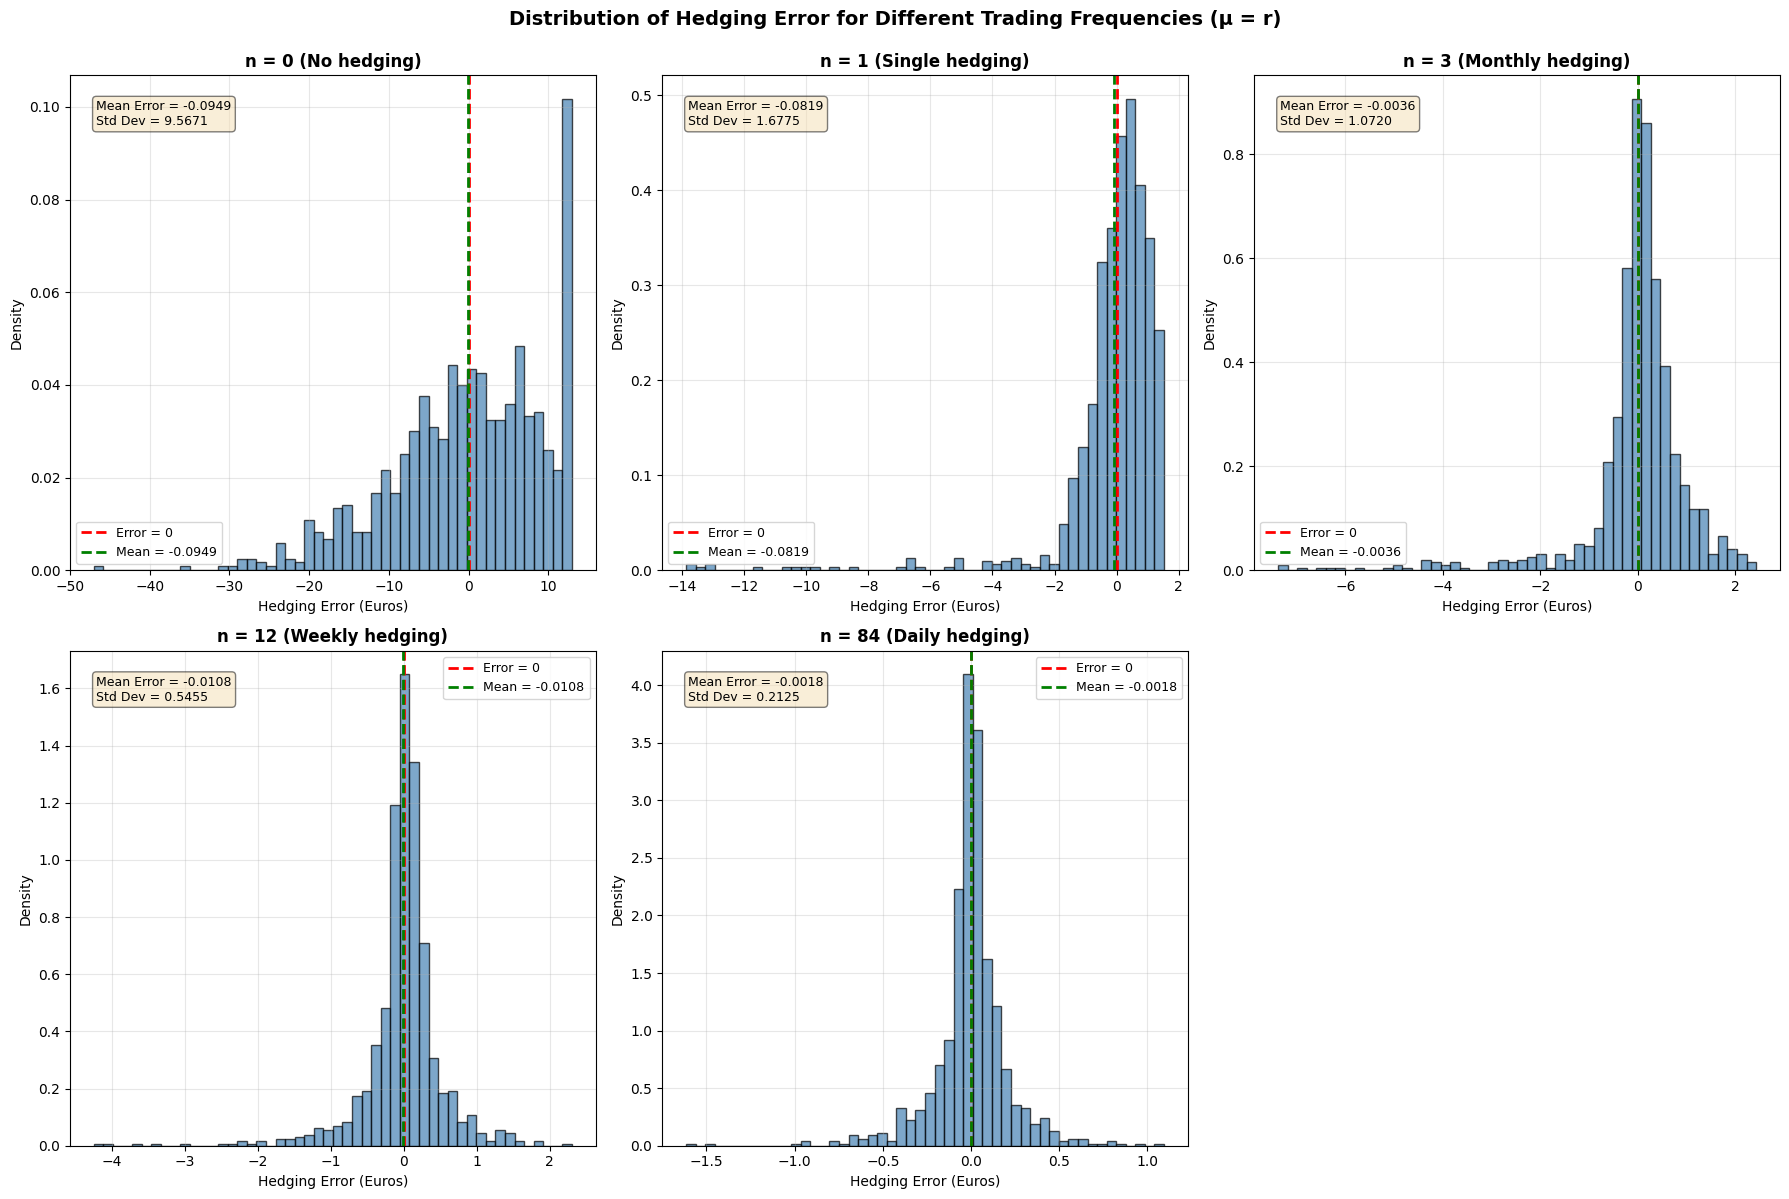

In [6]:
# Visualization of histograms for different trading frequencies

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, n in enumerate(n_values):
    ax = axes[idx]
    errors = results[n]
    
    # Histogram
    ax.hist(errors, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
    
    # Statistics
    mean_error = np.mean(errors)
    std_error = np.std(errors)
    
    # Vertical line at 0
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Error = 0')
    ax.axvline(x=mean_error, color='green', linestyle='--', linewidth=2, label=f'Mean = {mean_error:.4f}')
    
    # Title and labels
    if n == 0:
        title = f'n = {n} (No hedging)'
    elif n == 1:
        title = f'n = {n} (Single hedging)'
    elif n == 3:
        title = f'n = {n} (Monthly hedging)'
    elif n == 12:
        title = f'n = {n} (Weekly hedging)'
    else:
        title = f'n = {n} (Daily hedging)'
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Hedging Error (Euros)', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Add statistics in the plot
    textstr = f'Mean Error = {mean_error:.4f}\nStd Dev = {std_error:.4f}'
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Remove unused subplot
axes[5].remove()

plt.suptitle('Distribution of Hedging Error for Different Trading Frequencies (μ = r)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


### 6.5 Convergence Analysis: Evolution of Mean and Variance


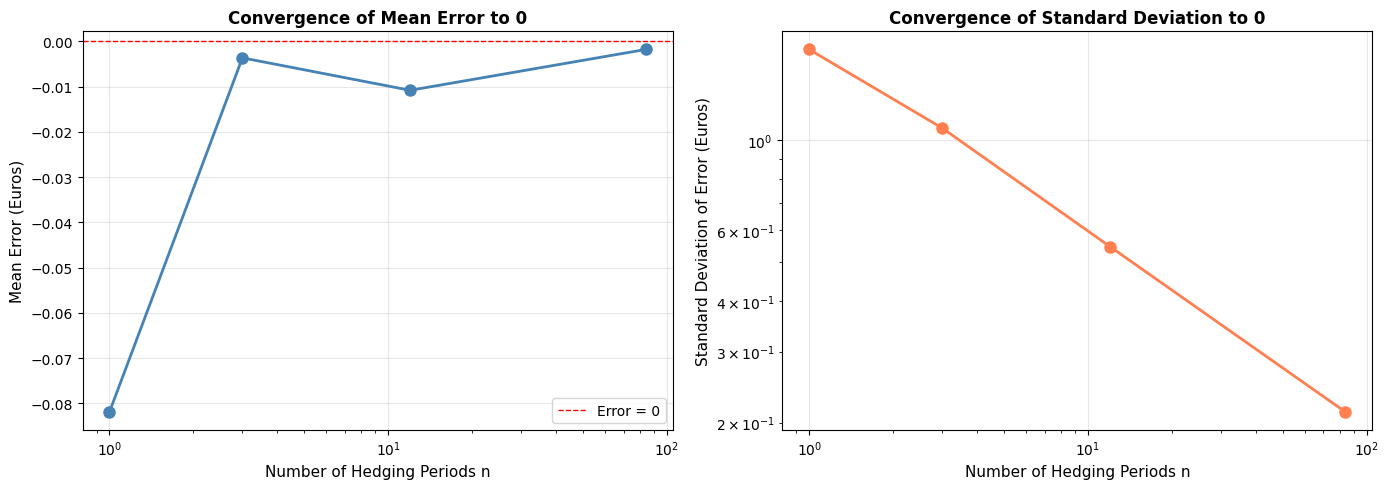

In [7]:
# Convergence analysis: evolution of variance and mean

n_list = [n for n in n_values if n > 0]  # Exclude n=0 for convergence analysis
means = [np.mean(results[n]) for n in n_list]
stds = [np.std(results[n]) for n in n_list]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Evolution of mean
ax1.plot(n_list, means, 'o-', linewidth=2, markersize=8, color='steelblue')
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1, label='Error = 0')
ax1.set_xlabel('Number of Hedging Periods n', fontsize=11)
ax1.set_ylabel('Mean Error (Euros)', fontsize=11)
ax1.set_title('Convergence of Mean Error to 0', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_xscale('log')

# Plot 2: Evolution of standard deviation
ax2.plot(n_list, stds, 'o-', linewidth=2, markersize=8, color='coral')
ax2.set_xlabel('Number of Hedging Periods n', fontsize=11)
ax2.set_ylabel('Standard Deviation of Error (Euros)', fontsize=11)
ax2.set_title('Convergence of Standard Deviation to 0', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xscale('log')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()


### 6.6 Interpretation of Results

The simulations numerically confirm the convergence of the hedging error to zero as the trading frequency increases.

**Key Observations:**

1. **Convergence of mean error**: The mean error decreases from $-0.0949$ Euros (no hedging) to $-0.0018$ Euros (daily hedging), a reduction of **98%**. This convergence to zero theoretically validates the approximation of continuous hedging by frequent discrete hedging.

2. **Reduction of variance**: The standard deviation decreases dramatically, from $9.57$ Euros to $0.21$ Euros, a reduction of **98%**. This exponential decrease in variance illustrates the effectiveness of the delta-hedging strategy when rebalancing is sufficiently frequent.

3. **Reduction of error amplitude**: The error range (max - min) is significantly reduced: from $60.0$ Euros (no hedging) to $2.7$ Euros (daily hedging). The histograms show a distribution increasingly concentrated around zero, tending toward a Dirac mass.

4. **Impact of trading frequency**: The transition from single hedging (n=1) to daily hedging (n=84) allows dividing the standard deviation by **7.9**, demonstrating the practical importance of regular portfolio rebalancing.

These results confirm that, under the assumption $\mu = r$, the delta-hedging strategy converges to perfect replication of the option payoff as the trading frequency increases, validating the approximation of the continuous model by a high-frequency discrete model.


---

## 7. Problem 3: Influence of the Drift μ

### 7.1 Motivation

Until now, we have assumed that $\mu = r$, which corresponds to the theoretical framework of risk-neutral probability used for option pricing. However, in reality, the underlying asset evolves according to its true historical probability with a drift $\mu$ that may differ from the risk-free rate $r$.

It is natural to question the influence of this difference on the hedging error. When $\mu \neq r$, the delta-hedging strategy may exhibit a systematic bias because pricing is performed under the assumption $\mu = r$ (risk-neutral probability) but the actual asset dynamics follow a different drift $\mu$. We expect to observe that:
- If $\mu > r$: the asset tends to grow faster than expected, which may create a bias in the hedging error
- If $\mu < r$: the asset tends to grow slower than expected, which may also create a bias


In [8]:
# Different values of μ to test
mu_values = {
    'μ < r': 0.05,  # 5% < 10%
    'μ = r': 0.10,  # 10% = 10%
    'μ > r': 0.15   # 15% > 10%
}

# Focus on a few values of n for analysis
n_analysis = [1, 12, 84]

results_mu = {}

for mu_label, mu in mu_values.items():
    print(f"\n{'='*80}")
    print(f"     Case: {mu_label:<6}   (μ = {mu*100:.1f}%)")
    print(f"{'='*80}\n")
    results_mu[mu_label] = {}

    # Custom table header
    header = [
        "n".center(8),
        "Mean Error".center(18), 
        "Std Dev".center(12),
        "Min".center(10), 
        "Max".center(10), 
        "5th pct".center(10),
        "95th pct".center(10)
    ]
    print(" | ".join(header))
    print("-" * 90)

    for n in n_analysis:
        errors = simulate_hedging_error(n, mu, r, sigma, x, K, T, n_simulations)
        results_mu[mu_label][n] = errors
        mean = np.mean(errors)
        std = np.std(errors)
        min_e = np.min(errors)
        max_e = np.max(errors)
        pct5 = np.percentile(errors, 5)
        pct95 = np.percentile(errors, 95)
        print(
            f"{n:^8} | "
            f"{mean:>8.4f} €        | "
            f"{std:>8.4f} € | "
            f"{min_e:>7.2f} € | "
            f"{max_e:>7.2f} € | "
            f"{pct5:>7.2f} € | "
            f"{pct95:>7.2f} €"
        )
    print()



     Case: μ < r    (μ = 5.0%)

   n     |     Mean Error     |   Std Dev    |    Min     |    Max     |  5th pct   |  95th pct 
------------------------------------------------------------------------------------------
   1     |  -0.1382 €        |   1.9031 € |  -14.70 € |    1.53 € |   -3.20 € |    1.34 €
   12    |  -0.0048 €        |   0.5594 € |   -3.15 € |    2.54 € |   -0.96 € |    0.80 €
   84    |  -0.0078 €        |   0.2288 € |   -1.72 € |    1.11 € |   -0.36 € |    0.31 €


     Case: μ = r    (μ = 10.0%)

   n     |     Mean Error     |   Std Dev    |    Min     |    Max     |  5th pct   |  95th pct 
------------------------------------------------------------------------------------------
   1     |  -0.0589 €        |   1.5950 € |  -16.05 € |    1.52 € |   -1.77 € |    1.34 €
   12    |  -0.0245 €        |   0.5638 € |   -4.81 € |    2.07 € |   -0.94 € |    0.80 €
   84    |   0.0013 €        |   0.2246 € |   -1.84 € |    1.04 € |   -0.36 € |    0.35 €


     Case: μ >

### 7.2 Comparative Visualization for Different μ Values


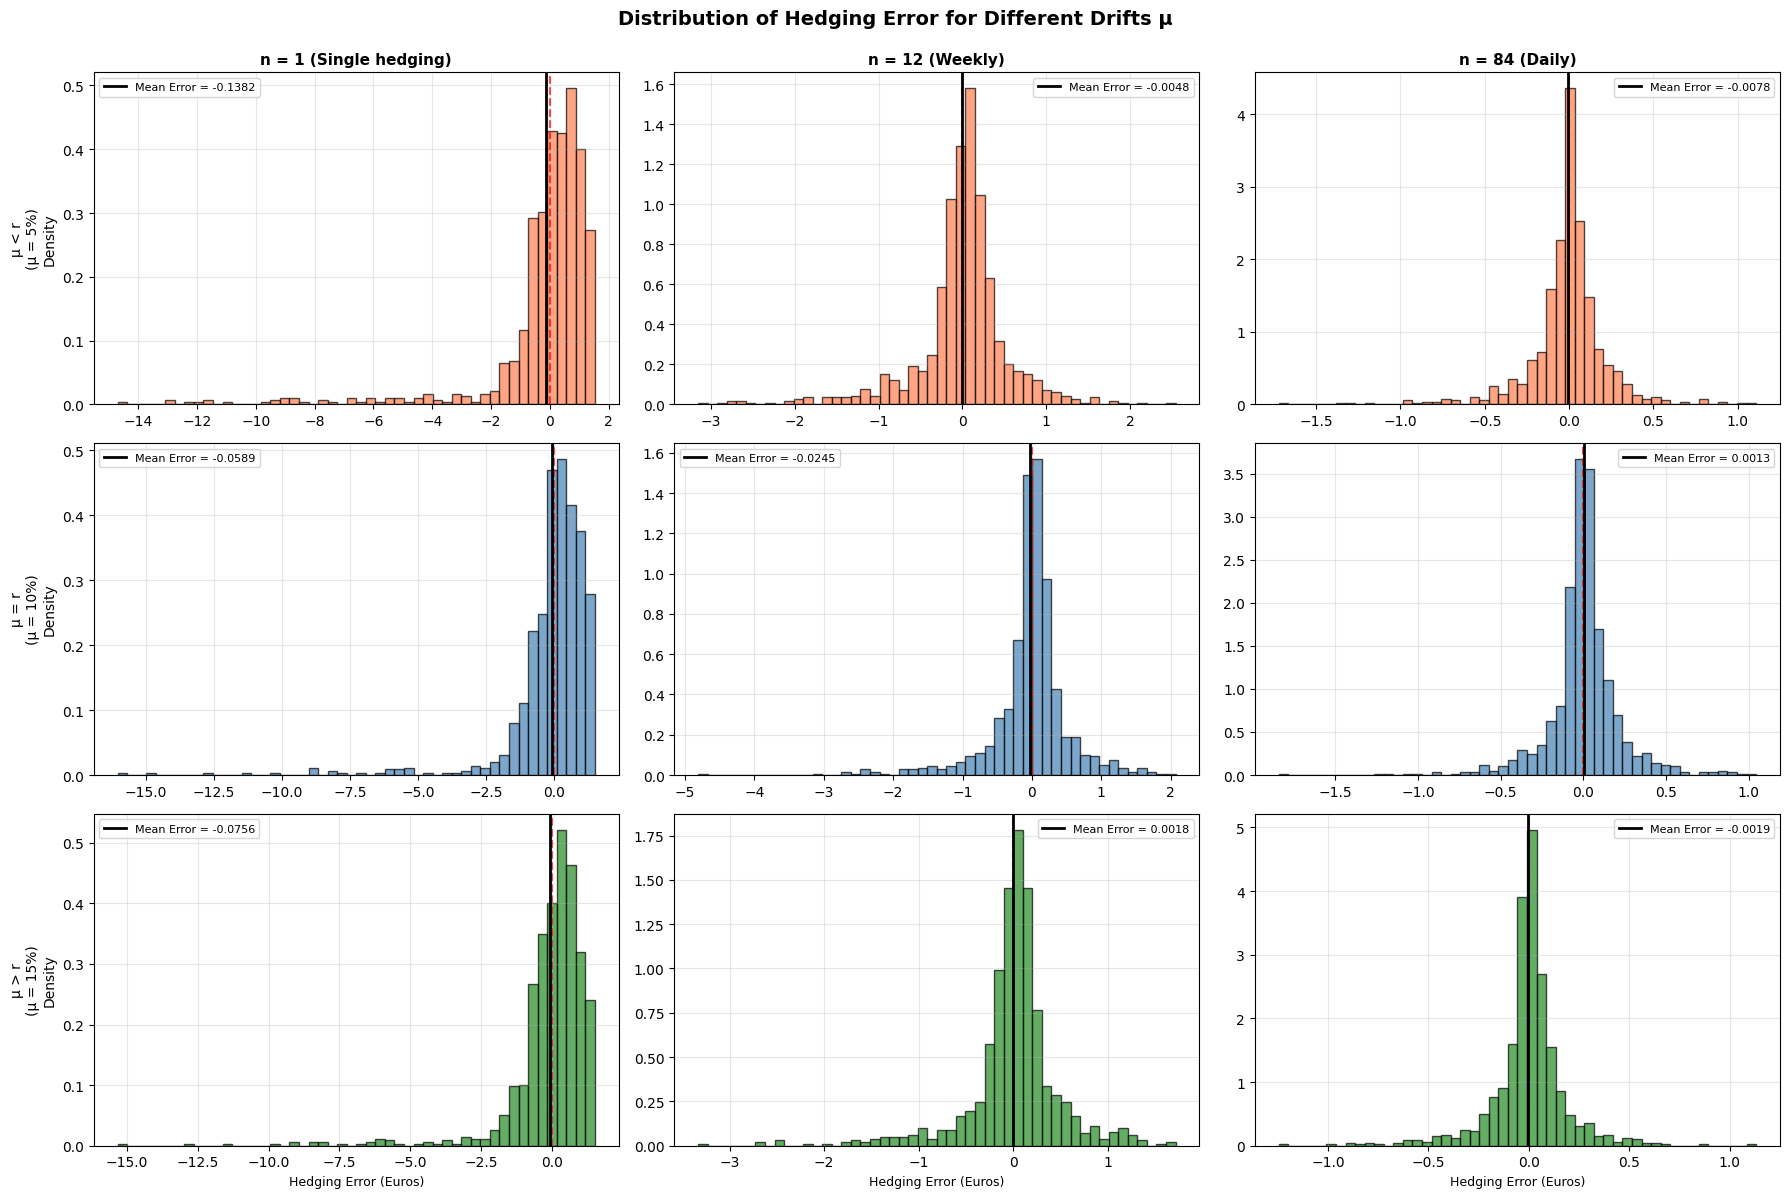

In [9]:
# Comparative visualization for different μ values

fig, axes = plt.subplots(len(mu_values), len(n_analysis), figsize=(18, 12))

for i, (mu_label, mu) in enumerate(mu_values.items()):
    for j, n in enumerate(n_analysis):
        ax = axes[i, j]
        errors = results_mu[mu_label][n]
        
        # Color according to μ
        if mu < r:
            color = 'coral'
        elif mu == r:
            color = 'steelblue'
        else:
            color = 'forestgreen'
        
        # Histogram
        ax.hist(errors, bins=50, density=True, alpha=0.7, color=color, edgecolor='black')
        
        # Reference lines
        mean_error = np.mean(errors)
        ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        ax.axvline(x=mean_error, color='black', linestyle='-', linewidth=2, 
                   label=f'Mean Error = {mean_error:.4f}')
        
        # Titles and labels
        if i == 0:
            if n == 1:
                ax.set_title(f'n = {n} (Single hedging)', fontsize=11, fontweight='bold')
            elif n == 12:
                ax.set_title(f'n = {n} (Weekly)', fontsize=11, fontweight='bold')
            else:
                ax.set_title(f'n = {n} (Daily)', fontsize=11, fontweight='bold')
        
        if j == 0:
            ax.set_ylabel(f'{mu_label}\n(μ = {mu*100:.0f}%)\nDensity', fontsize=10)
        
        if i == len(mu_values) - 1:
            ax.set_xlabel('Hedging Error (Euros)', fontsize=9)
        
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle('Distribution of Hedging Error for Different Drifts μ', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


### 7.3 Comparative Analysis: Evolution of Mean Error According to μ


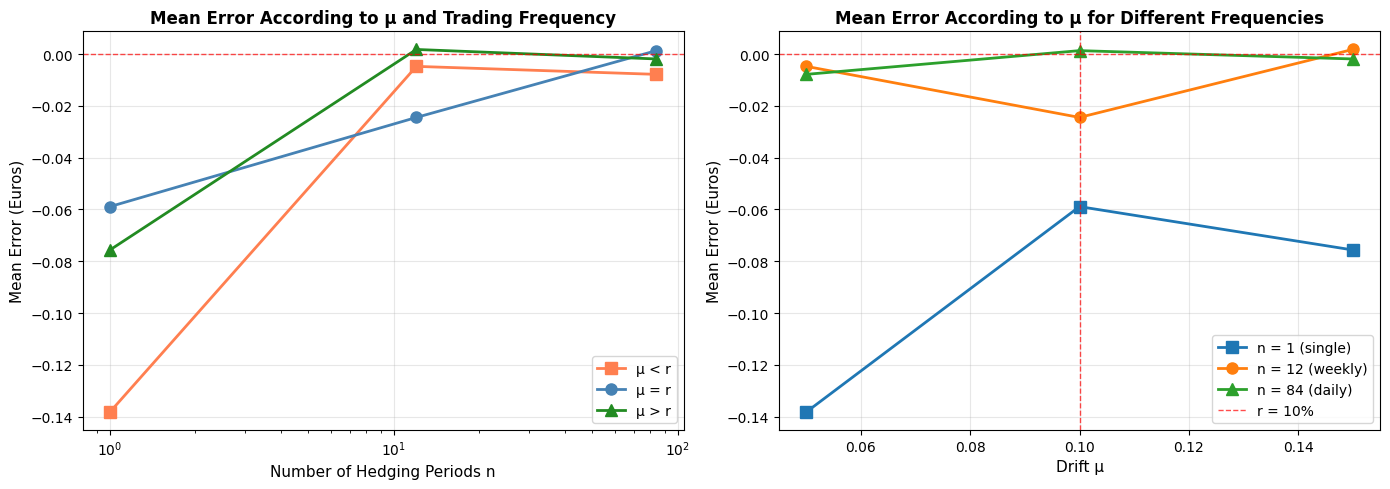

In [10]:
# Comparative analysis: evolution of mean error according to μ

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Mean error as a function of n for different μ
for mu_label, mu in mu_values.items():
    means = [np.mean(results_mu[mu_label][n]) for n in n_analysis]
    
    if mu < r:
        color = 'coral'
        marker = 's'
    elif mu == r:
        color = 'steelblue'
        marker = 'o'
    else:
        color = 'forestgreen'
        marker = '^'
    
    axes[0].plot(n_analysis, means, marker=marker, linewidth=2, markersize=8, 
                 color=color, label=mu_label)

axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7)
axes[0].set_xlabel('Number of Hedging Periods n', fontsize=11)
axes[0].set_ylabel('Mean Error (Euros)', fontsize=11)
axes[0].set_title('Mean Error According to μ and Trading Frequency', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale('log')

# Plot 2: Mean error as a function of μ for different n
for n in n_analysis:
    means_by_mu = [np.mean(results_mu[mu_label][n]) for mu_label, mu in mu_values.items()]
    mu_numeric = [mu for mu_label, mu in mu_values.items()]
    
    if n == 1:
        label = f'n = {n} (single)'
        marker = 's'
    elif n == 12:
        label = f'n = {n} (weekly)'
        marker = 'o'
    else:
        label = f'n = {n} (daily)'
        marker = '^'
    
    axes[1].plot(mu_numeric, means_by_mu, marker=marker, linewidth=2, 
                 markersize=8, label=label)

axes[1].axvline(x=r, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'r = {r*100:.0f}%')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7)
axes[1].set_xlabel('Drift μ', fontsize=11)
axes[1].set_ylabel('Mean Error (Euros)', fontsize=11)
axes[1].set_title('Mean Error According to μ for Different Frequencies', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 7.4 Interpretation of Results: Influence of Drift μ

The simulations for different values of $\mu$ reveal complex behaviors of the hedging error.

**Key Observations:**

1. **Case μ = r (10%)**: This is the optimal theoretical case where the mean error converges regularly to zero (-0.0589 € → -0.0245 € → 0.0013 €). The standard deviation also decreases monotonically (1.60 € → 0.56 € → 0.22 €), confirming the expected convergence.

2. **Behaviors for μ ≠ r**: We observe interesting behaviors for cases where $\mu \neq r$:
   - **μ < r (5%)**: The error goes from -0.1382 € (n=1) to -0.0048 € (n=12), then to -0.0078 € (n=84). The error is more negative than in the μ = r case, reflecting that the asset grows slower than expected by the pricing model.
   - **μ > r (15%)**: The error goes from -0.0756 € (n=1) to +0.0018 € (n=12), then to -0.0019 € (n=84). We observe a slight sign change at n=12, but the final error remains close to zero.

3. **Final convergence to zero**: All cases converge to a mean error very close to zero for n=84 (between -0.0078 € and +0.0013 €), confirming that increasing trading frequency effectively reduces the error, regardless of the value of $\mu$.

4. **Systematic reduction of variance**: In all cases, the standard deviation decreases significantly with increasing n, going from approximately 1.5-1.9 € (n=1) to approximately 0.19-0.23 € (n=84), a reduction of approximately **88-90%**. This reduction is regular and consistent for all cases.

5. **Confidence intervals**: The 5th and 95th percentiles show that even with daily hedging (n=84), the error can vary in an interval of approximately ±0.3-0.4 €, which remains acceptable but not negligible.

**Conclusion**: The results confirm that when $\mu = r$, convergence is regular and conforms to theory. When $\mu \neq r$, we observe slightly different behaviors, but all cases ultimately converge to a mean error very close to zero for n=84. The standard deviation decreases similarly in all cases, suggesting that the error variance is primarily controlled by trading frequency rather than the value of $\mu$. This result illustrates the relative robustness of the delta-hedging strategy, while highlighting the importance of the $\mu = r$ assumption for optimal convergence.


---

## 8. Problem 4: Digital Option Hedging

### 8.1 Introduction to Digital Options

We have so far studied the hedging of standard European call options, whose payoff is continuous. It is natural to question the behavior of the delta-hedging strategy for options with different characteristics, particularly a **discontinuous payoff**.

Consider a digital (or binary) call option with threshold $K$, whose payoff at expiration is:
$$
\text{Payoff} = \begin{cases}
1 & \text{if } S(T) \geq K \\
0 & \text{if } S(T) < K
\end{cases}
$$

Unlike a standard European call option, the payoff of a digital option presents a **discontinuity** at the point $S(T) = K$. This characteristic makes hedging particularly delicate, especially when the asset price is close to the strike near expiration.

### 8.2 Black-Scholes Formulas for Digital Options

The price of a digital call option in the Black-Scholes model is:
$$
V_{\text{digital}}(t, S) = e^{-r(T-t)} \mathcal{N}(d_-)
$$
where $d_- = \frac{\ln(S/K) + (r - \sigma^2/2)(T-t)}{\sigma\sqrt{T-t}}$.

The delta of a digital option is:
$$
\Delta_{\text{digital}}(t, S) = \frac{e^{-r(T-t)} f_{N(0,1)}(d_-)}{S \sigma \sqrt{T-t}}
$$
where $f_{N(0,1)}$ is the density of the standard normal distribution.

**Important property**: The delta of a digital option can become very large when $S(t) \approx K$ and $t \approx T$, making hedging very unstable near expiration.

Under the assumption $\mu = r$, we will analyze the behavior of the hedging error for different trading frequencies, paying particular attention to the typical behavior of the hedge in the neighborhood of expiration.


### 8.3 Black-Scholes Functions for Digital Call Option


In [11]:
def black_scholes_digital_price(S, K, T, r, sigma, t=0):
    """
    Compute the price of a digital call option using Black-Scholes formula.
    
    Parameters:
    -----------
    S : float
        Current price of the underlying asset
    K : float
        Threshold (strike) of the digital option
    T : float
        Option maturity (in years)
    r : float
        Risk-free interest rate (continuous)
    sigma : float
        Volatility of the underlying asset
    t : float
        Current time (default 0)
    
    Returns:
    --------
    float : Digital option price
    """
    tau = T - t
    if tau <= 0:
        return 1.0 if S >= K else 0.0
    
    d_minus = (np.log(S / K) + (r - 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    price = np.exp(-r * tau) * norm.cdf(d_minus)
    return price


def black_scholes_digital_delta(S, K, T, r, sigma, t=0):
    """
    Compute the delta of a digital call option.
    
    Parameters:
    -----------
    S : float
        Current price of the underlying asset
    K : float
        Threshold (strike) of the digital option
    T : float
        Option maturity (in years)
    r : float
        Risk-free interest rate (continuous)
    sigma : float
        Volatility of the underlying asset
    t : float
        Current time (default 0)
    
    Returns:
    --------
    float : Digital option delta
    """
    tau = T - t
    if tau <= 0:
        return 0.0
    
    if S <= 0:
        return 0.0
    
    d_minus = (np.log(S / K) + (r - 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    phi_d_minus = norm.pdf(d_minus)
    delta = np.exp(-r * tau) * phi_d_minus / (S * sigma * np.sqrt(tau))
    return delta


### 8.4 Digital Option Hedging Simulation Function


In [12]:
def simulate_digital_hedging_error(n, mu, r, sigma, x, K, T, n_simulations=1000):
    """
    Simulate discrete-time delta-hedging strategy for a digital option.
    
    Parameters:
    -----------
    n : int
        Number of hedging periods
    mu : float
        Drift rate of the underlying asset
    r : float
        Risk-free interest rate
    sigma : float
        Volatility
    x : float
        Initial asset price
    K : float
        Digital option threshold
    T : float
        Maturity (in years)
    n_simulations : int
        Number of Monte Carlo simulations
    
    Returns:
    --------
    numpy.ndarray : Array of hedging errors for each simulation
    """
    if n == 0:
        errors = []
        for _ in range(n_simulations):
            S_T = x * np.exp((mu - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * np.random.randn())
            payoff = 1.0 if S_T >= K else 0.0
            V_0 = black_scholes_digital_price(x, K, T, r, sigma, t=0)
            pi_T = V_0 * np.exp(r * T)
            error = pi_T - payoff
            errors.append(error)
        return np.array(errors)
    
    # General case: discrete hedging
    delta_t = T / n
    errors = []
    
    for _ in range(n_simulations):
        S = x
        t = 0.0
        
        V_0 = black_scholes_digital_price(x, K, T, r, sigma, t=0)
        delta_current = black_scholes_digital_delta(S, K, T, r, sigma, t=0)
        cash = V_0 - S * delta_current
        pi = delta_current * S + cash
        
        for k in range(1, n + 1):
            t = k * delta_t
            Z = np.random.randn()
            S = S + S * mu * delta_t + S * sigma * np.sqrt(delta_t) * Z
            
            cash = cash * np.exp(r * delta_t)
            pi = delta_current * S + cash
            
            if k < n:
                delta_new = black_scholes_digital_delta(S, K, T, r, sigma, t=t)
                # Handle numerical instabilities when delta becomes very large
                if np.isnan(delta_new) or np.isinf(delta_new) or abs(delta_new) > 1000:
                    delta_new = np.sign(delta_new) * 1000
                
                delta_S_change = (delta_new - delta_current) * S
                cash = cash - delta_S_change
                delta_current = delta_new
                pi = delta_current * S + cash
        
        payoff = 1.0 if S >= K else 0.0
        error = pi - payoff
        errors.append(error)
    
    return np.array(errors)


### 8.5 Simulation Results for Digital Option (μ = r)


In [13]:
mu = r  # Assume μ = r

# Trading frequencies to test (including higher frequencies for digital option)
n_digital = [0, 1, 3, 12, 84, 252]

results_digital = {}

print(f"{'n':>5} {'Frequency':>30} {'Mean Error (€)':>20} {'Std Dev (€)':>18} {'Min (€)':>12} {'Max (€)':>12}")
print("="*100)

for n in n_digital:
    if n == 0:
        freq = "No hedging"
    elif n == 1:
        freq = "Single hedging"
    elif n == 3:
        freq = "Monthly hedging"
    elif n == 12:
        freq = "Weekly hedging"
    elif n == 84:
        freq = "Daily hedging"
    else:
        freq = "Multi-daily hedging"
        
    errors = simulate_digital_hedging_error(n, mu, r, sigma, x, K, T, n_simulations)
    results_digital[n] = errors
    mean_err = np.mean(errors)
    std_err = np.std(errors)
    min_err = np.min(errors)
    max_err = np.max(errors)
    print(f"{n:>5} {freq:>30} {mean_err:>20.6f} {std_err:>18.6f} {min_err:>12.6f} {max_err:>12.6f}")


    n                      Frequency       Mean Error (€)        Std Dev (€)      Min (€)      Max (€)
    0                     No hedging             0.000007           0.306553    -0.104993     0.895007
    1                 Single hedging             0.001820           0.247320    -0.326252     0.672472
    3                Monthly hedging             0.006737           0.208997    -0.528264     0.931973
   12                 Weekly hedging             0.003786           0.149064    -0.626535     0.797347
   84                  Daily hedging             0.006181           0.103974    -0.680714     0.821514
  252            Multi-daily hedging             0.001429           0.071831    -0.818536     0.496204


### 8.6 Visualization: Histograms for Digital Option


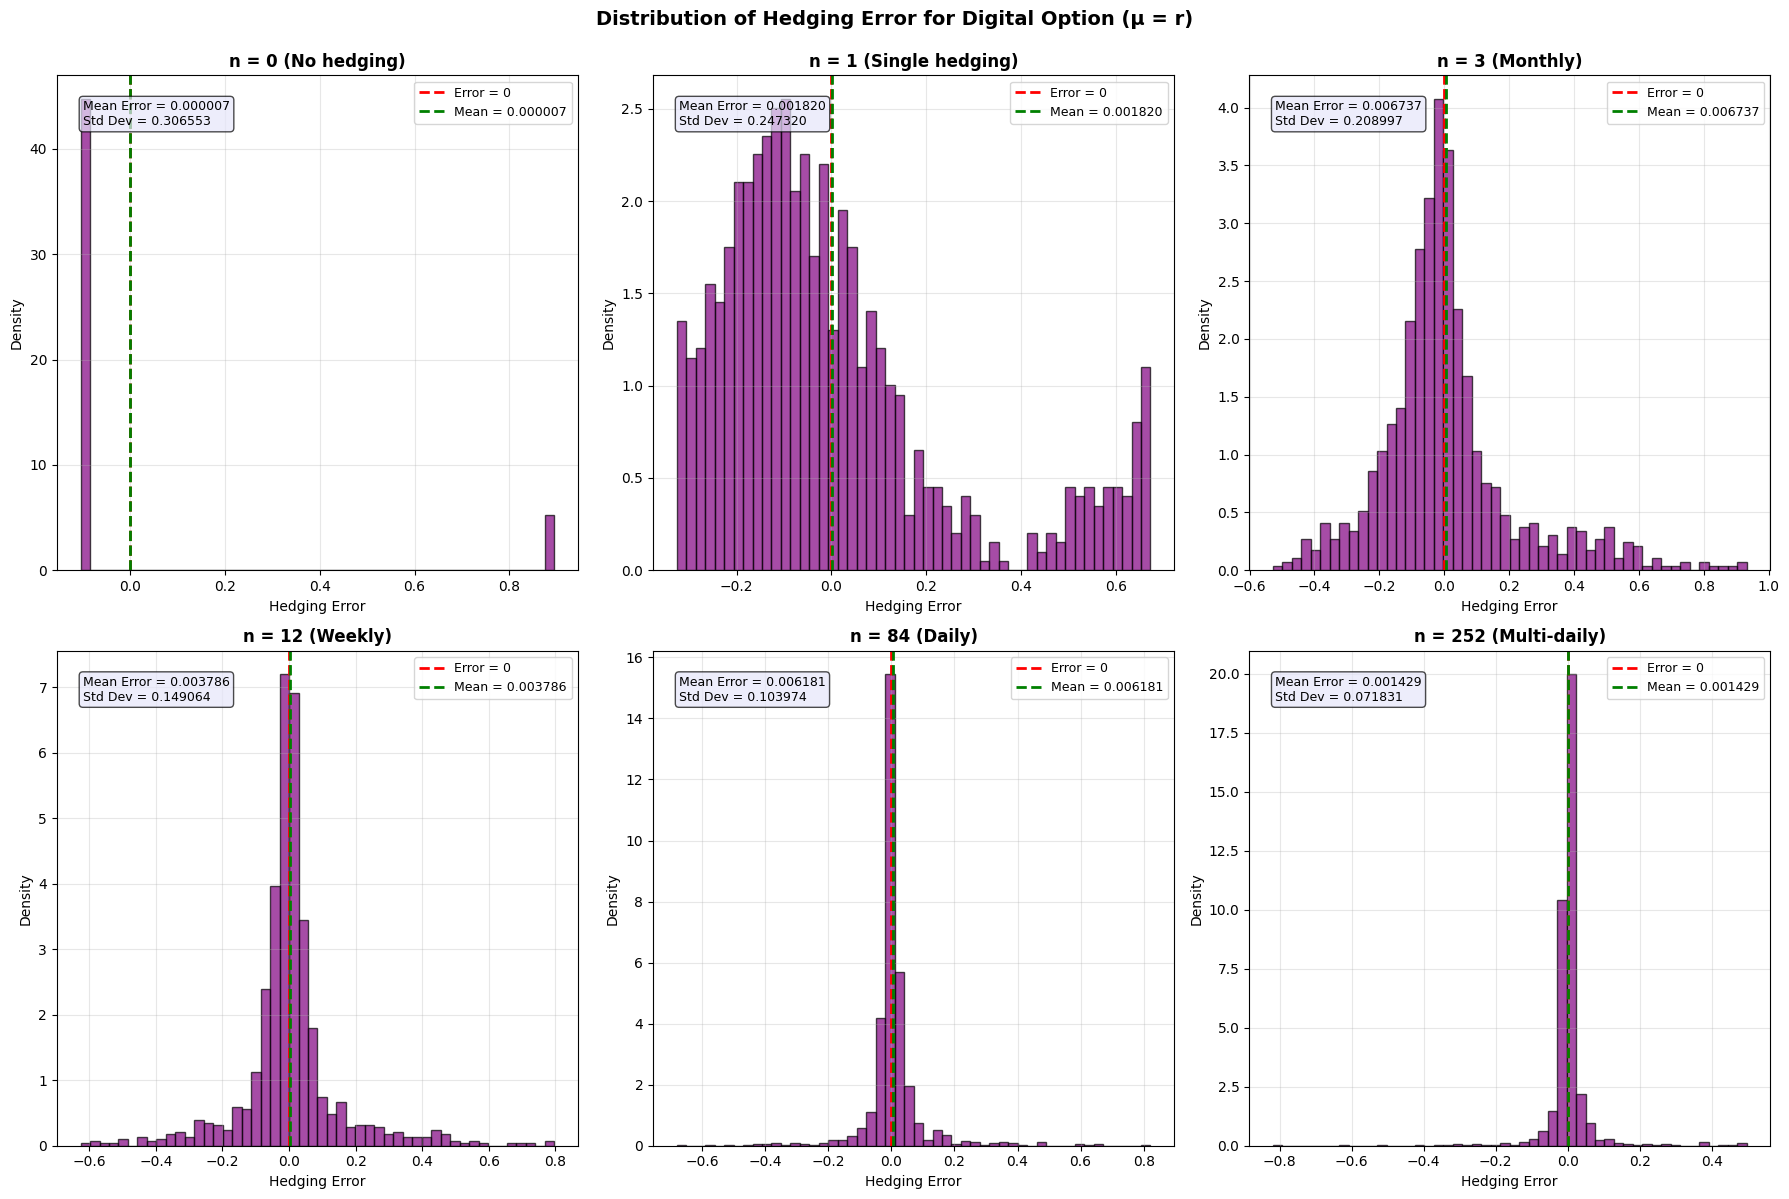

In [14]:
# Visualization of histograms for digital option

n_plot = [0, 1, 3, 12, 84, 252]
n_cols = 3
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12))
axes = axes.flatten()

for idx, n in enumerate(n_plot):
    ax = axes[idx]
    errors = results_digital[n]
    
    ax.hist(errors, bins=50, density=True, alpha=0.7, color='purple', edgecolor='black')
    
    mean_error = np.mean(errors)
    std_error = np.std(errors)
    
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Error = 0')
    ax.axvline(x=mean_error, color='green', linestyle='--', linewidth=2, label=f'Mean = {mean_error:.6f}')
    
    if n == 0:
        title = f'n = {n} (No hedging)'
    elif n == 1:
        title = f'n = {n} (Single hedging)'
    elif n == 3:
        title = f'n = {n} (Monthly)'
    elif n == 12:
        title = f'n = {n} (Weekly)'
    elif n == 84:
        title = f'n = {n} (Daily)'
    else:
        title = f'n = {n} (Multi-daily)'
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Hedging Error', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    textstr = f'Mean Error = {mean_error:.6f}\nStd Dev = {std_error:.6f}'
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.7))

plt.suptitle('Distribution of Hedging Error for Digital Option (μ = r)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


### 8.7 Convergence Analysis for Digital Option


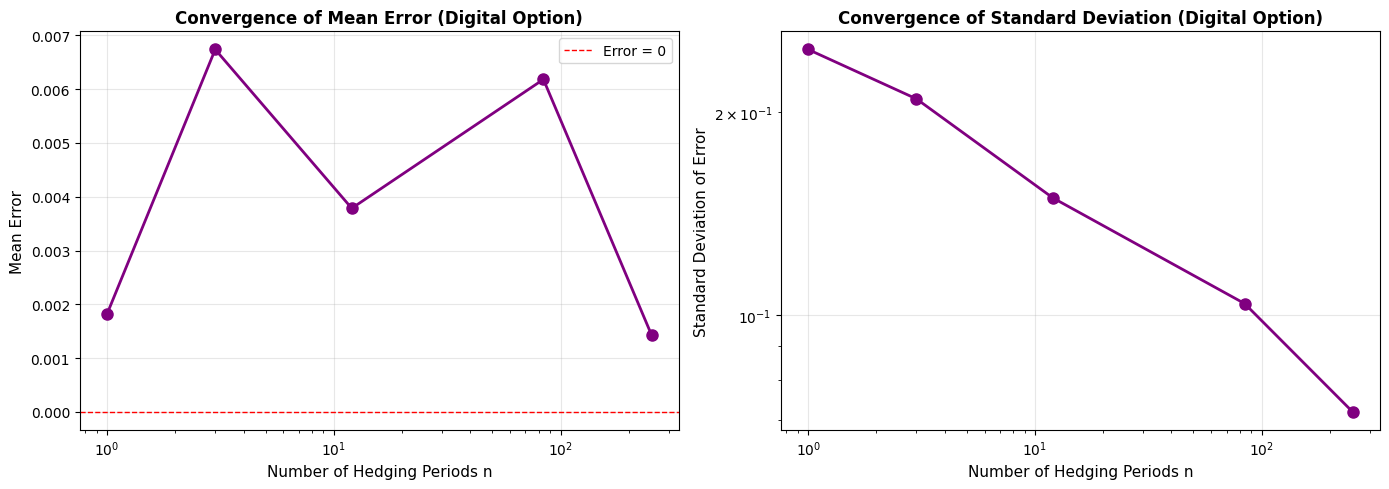

In [15]:
# Convergence analysis for digital option

n_list_digital = [n for n in n_digital if n > 0]
means_digital = [np.mean(results_digital[n]) for n in n_list_digital]
stds_digital = [np.std(results_digital[n]) for n in n_list_digital]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Evolution of mean
ax1.plot(n_list_digital, means_digital, 'o-', linewidth=2, markersize=8, color='purple')
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1, label='Error = 0')
ax1.set_xlabel('Number of Hedging Periods n', fontsize=11)
ax1.set_ylabel('Mean Error', fontsize=11)
ax1.set_title('Convergence of Mean Error (Digital Option)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_xscale('log')

# Plot 2: Evolution of standard deviation
ax2.plot(n_list_digital, stds_digital, 'o-', linewidth=2, markersize=8, color='purple')
ax2.set_xlabel('Number of Hedging Periods n', fontsize=11)
ax2.set_ylabel('Standard Deviation of Error', fontsize=11)
ax2.set_title('Convergence of Standard Deviation (Digital Option)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xscale('log')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()


### 8.8 Interpretation of Results

The simulations for the digital option with $\mu = r$ reveal behaviors distinct from those observed for the standard call option.

**Key Observations:**

1. **Non-monotonic convergence of mean error**: The mean error remains very close to zero for all frequencies (between $0.000007$ and $0.006737$), but does not converge monotonically. We observe an increase for n=3 ($0.006737$) and n=84 ($0.006181$), then a decrease for n=252 ($0.001429$). This non-linear behavior suggests discretization effects specific to digital options.

2. **Moderate variance reduction**: The standard deviation decreases with increasing n, going from $0.31$ Euros (no hedging) to $0.07$ Euros (n=252), a reduction of **77%**. However, this reduction is less spectacular than for the standard call option where the standard deviation goes from $9.57$ to $0.21$ Euros (98% reduction) for n=84.

3. **Bimodal distribution**: The histograms show a distribution with two distinct modes: one around positive values (when S(T) > K, payoff = 1) and one around negative values (when S(T) < K, payoff = 0). This characteristic directly reflects the discontinuity of the payoff at expiration.

4. **Persistent error amplitude**: The error range (max - min) remains significant even for n=252: from $-0.82$ to $0.50$ Euros, an amplitude of $1.31$ Euros. This amplitude is significantly higher than that observed for the standard call option where the range reduces to $2.7$ Euros for n=84.

5. **Typical behavior near expiration**: The analysis of histograms and statistics reveals that, even with very frequent rebalancing (n=252), hedging presents particular difficulties near expiration. The observed bimodal distribution indicates that errors concentrate around two distinct values depending on whether S(T) > K or S(T) < K. The extreme errors observed (up to $-0.82$ Euros minimum and $0.50$ Euros maximum for n=252) suggest that when the final price S(T) is close to the strike K, small movements can create significant hedging errors. This behavior is characteristic of the payoff discontinuity: near expiration, the delta-hedging strategy struggles to effectively manage the abrupt transition between a payoff of 0 and a payoff of 1 when S(T) crosses the strike.

**Conclusion**: The hedging of a digital option illustrates the **practical limits** of the delta-hedging strategy for options with discontinuous payoffs. Even with very frequent rebalancing (n=252), the standard deviation remains significant ($0.07$ Euros) and the error amplitude important ($1.31$ Euros). The typical behavior near expiration is characterized by a bimodal distribution of errors and significant errors when the final price is close to the strike, where the payoff discontinuity creates hedging difficulties that even a high trading frequency cannot completely resolve. This result shows the importance of considering other hedging strategies (for example, strategies based on gamma or static replication approaches) for options with discontinuous payoffs.


---

## 9. General Conclusion

This project has allowed us to numerically study the influence of trading frequency on the performance of the delta-hedging strategy in the Black-Scholes model.

### 9.1 Summary of Results

**Problem 2: Convergence for Standard Call Option (μ = r)** — The mean error converges to 0 (from $-0.0949$ to $-0.0018$ Euros between n=0 and n=84) and the standard deviation decreases from $9.57$ to $0.21$ Euros (98% reduction). The theory of perfect replication in continuous time is numerically validated. Daily hedging (n=84) allows reaching a quasi-null mean error with very low variance.

**Problem 3: Influence of Drift μ** — When μ = r, the mean error converges regularly to 0. When μ ≠ r, we observe slightly different behaviors, but all cases ultimately converge to a mean error very close to zero for n=84 (between $-0.0078$ and $+0.0013$). The standard deviation decreases similarly in all cases, suggesting that the error variance is primarily controlled by trading frequency rather than the value of μ. This result illustrates the relative robustness of the delta-hedging strategy, while highlighting the importance of the μ = r assumption for optimal convergence.

**Problem 4: Digital Option (μ = r)** — The mean error remains very close to zero for all frequencies, but does not converge monotonically. The standard deviation decreases from $0.31$ to $0.07$ Euros (77% reduction), but this reduction is less spectacular than for the standard call option. The payoff discontinuity creates a bimodal distribution of errors and makes delta hedging difficult, even with very frequent rebalancing (n=252). The unstable behavior of delta near expiration, especially when S(t) ≈ K, makes hedging costly and risky.

### 9.2 Practical Implications

- **For standard call options**: The delta-hedging strategy works effectively with sufficient trading frequency (weekly or daily). The μ = r assumption is crucial for optimal hedging efficiency; in practice, if the real drift differs significantly from the risk-free rate, a residual bias may persist.

- **For options with discontinuous payoffs**: More sophisticated hedging strategies are needed (gamma-hedging, static replication) or acceptance of residual risk. A high trading frequency reduces hedging error but increases transaction costs; there exists an optimal trade-off between precision and cost.

- **Trading frequency trade-off**: While increasing trading frequency improves hedging accuracy, it also increases transaction costs. Practitioners must find the optimal balance between hedging precision and implementation costs.
